C:\Users\miy\miniconda3\envs\diceml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Models loaded: ['MiddleAged_Male', 'MiddleAged_Female', 'Older_Male', 'Older_Female']

Section 2: Model Calibration

  [MiddleAged_Male]
    Class 0: Brier = 0.2045
    Class 1: Brier = 0.1587
    Class 2: Brier = 0.1018
    Class 3: Brier = 0.1232
    Mean Brier: 0.1471

  [MiddleAged_Female]
    Class 0: Brier = 0.1746
    Class 1: Brier = 0.1066
    Class 2: Brier = 0.0633
    Class 3: Brier = 0.0349
    Mean Brier: 0.0949

  [Older_Male]
    Class 0: Brier = 0.1504
    Class 1: Brier = 0.2002
    Class 2: Brier = 0.1387
    Class 3: Brier = 0.2225
    Mean Brier: 0.1780

  [Older_Female]
    Class 0: Brier = 0.1789
    Class 1: Brier = 0.2361
    Class 2: Brier = 0.0959
    Class 3: Brier = 0.2119
    Mean Brier: 0.1807
  Saved: figure_calibration (PNG/PDF/TIFF 600 dpi)


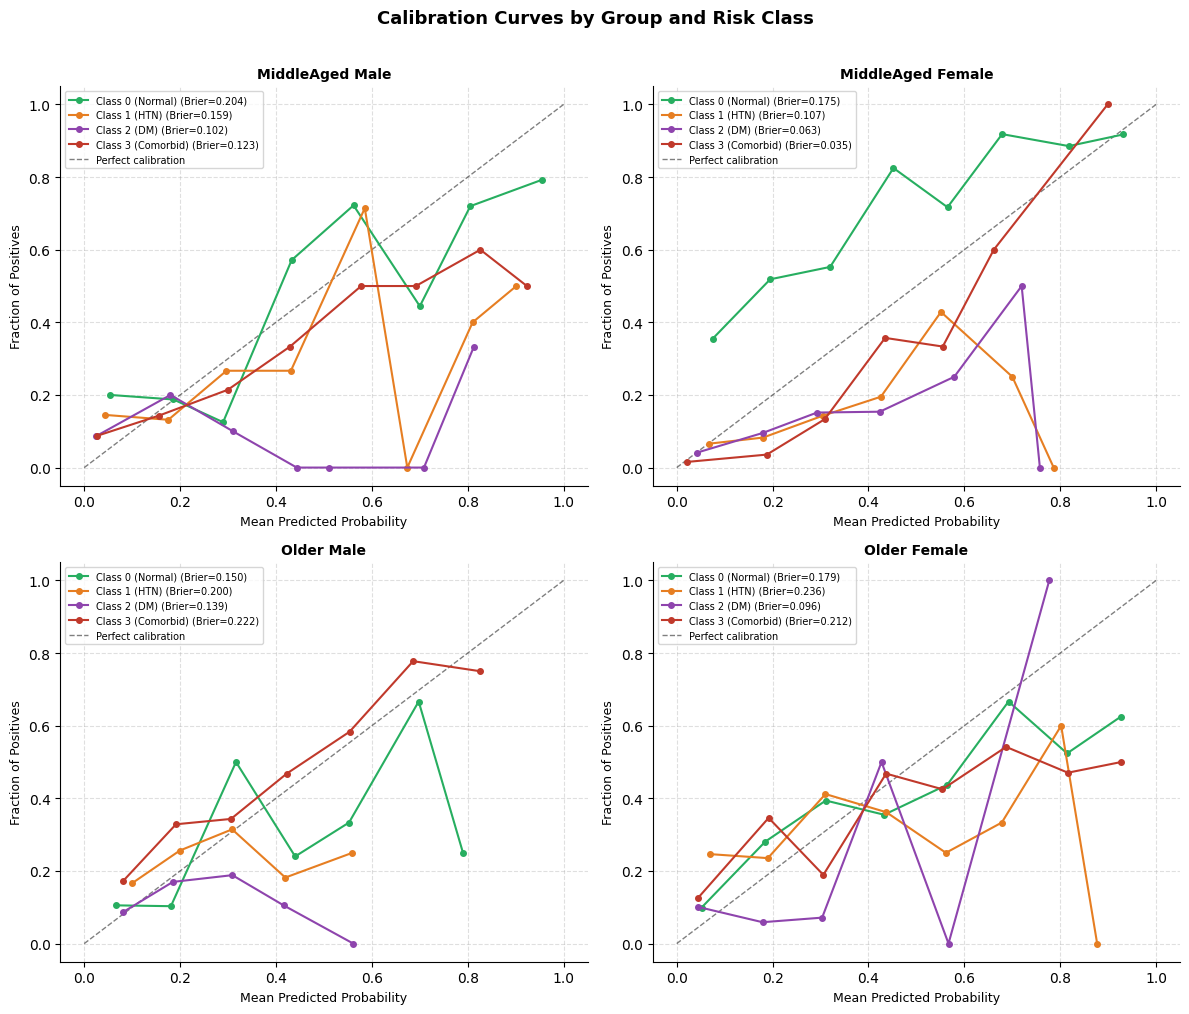


>>> Saved: ../results/tables/calibration_results.csv
            Group  Brier_Class0  Brier_Class1  Brier_Class2  Brier_Class3  Brier_Mean
  MiddleAged_Male        0.2045        0.1587        0.1018        0.1232      0.1471
MiddleAged_Female        0.1746        0.1066        0.0633        0.0349      0.0949
       Older_Male        0.1504        0.2002        0.1387        0.2225      0.1780
     Older_Female        0.1789        0.2361        0.0959        0.2119      0.1807

Section 3: SHAP Variable Importance

  [MiddleAged_Male] Top 5 features (Class 3 SHAP):
    WaistCirc                : 1.2060
    BMI                      : 0.3550
    Weight                   : 0.3153
    EducationLevel           : 0.2621
    BreakfastFrequency       : 0.2596

  [MiddleAged_Female] Top 5 features (Class 3 SHAP):
    WaistCirc                : 1.0474
    BMI                      : 0.6043
    Potassium_mg             : 0.2293
    Sodium_mg                : 0.2016
    Energy_kcal              : 

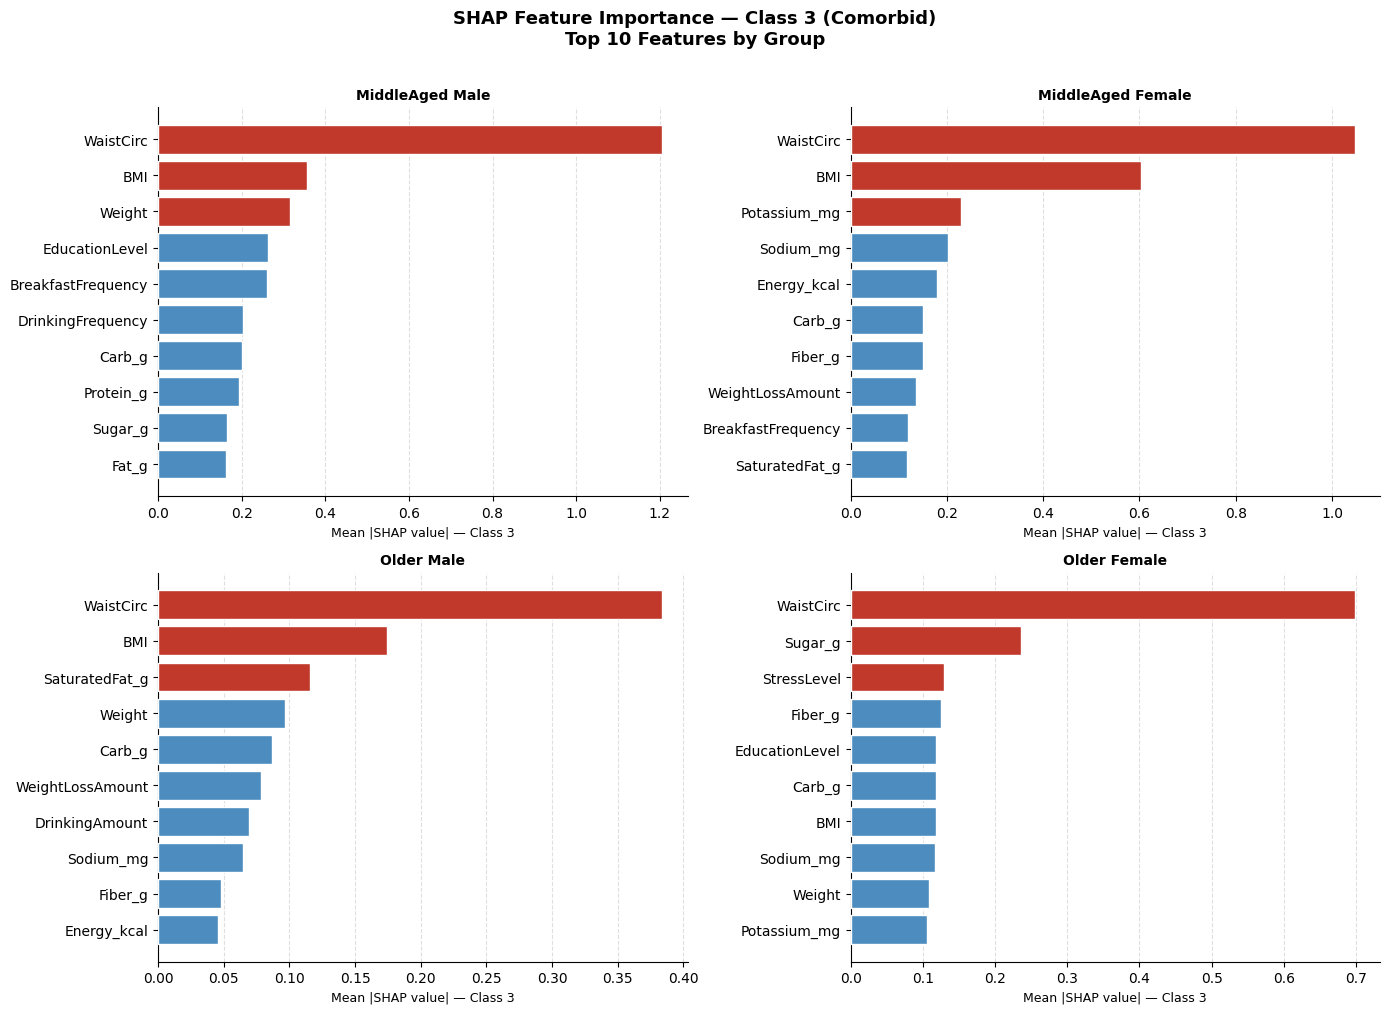


>>> Saved: ../results/tables/shap_importance.csv

Section 4: Stratification Effect Statistical Test

  Pooled model — Class 3 AUC: 0.8286

  [MiddleAged_Male]
    Stratified AUC (Class 3) : 0.7738
    Pooled AUC    (Class 3)  : 0.9730
    AUC diff (Strat-Pool)    : -0.1995 95% CI [-0.2803, -0.1269] p=0.0000  *
    McNemar χ²=19.0125  p=0.0  *

  [MiddleAged_Female]
    Stratified AUC (Class 3) : 0.8995
    Pooled AUC    (Class 3)  : 0.9882
    AUC diff (Strat-Pool)    : -0.0884 95% CI [-0.1506, -0.0326] p=0.0000  *
    McNemar χ²=46.0225  p=0.0  *

  [Older_Male]
    Stratified AUC (Class 3) : 0.6728
    Pooled AUC    (Class 3)  : 0.9352
    AUC diff (Strat-Pool)    : -0.2615 95% CI [-0.3186, -0.2013] p=0.0000  *
    McNemar χ²=78.0813  p=0.0  *

  [Older_Female]
    Stratified AUC (Class 3) : 0.6953
    Pooled AUC    (Class 3)  : 0.9069
    AUC diff (Strat-Pool)    : -0.2120 95% CI [-0.2601, -0.1660] p=0.0000  *
    McNemar χ²=74.9268  p=0.0  *

>>> Saved: ../results/tables/stratific

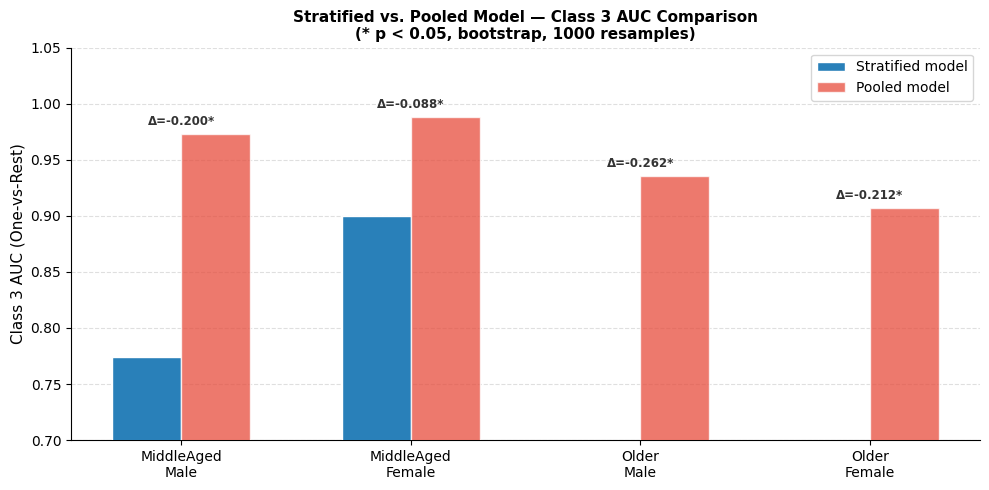

In [1]:
# 08_model_validation.ipynb
# =============================================================================
# Personalized Health Intervention Pathways for Comorbid Policyholders:
# Loss Ratio Management via LLM Guardrails and Counterfactual Explanations
# -----------------------------------------------------------------------------
# Notebook 08 — Model Calibration, SHAP Analysis & Stratification Test
#
# Contents:
#   1. Model calibration: Brier Score + Calibration curves (4 stratified models)
#   2. SHAP variable importance: group-level feature contribution analysis
#   3. Stratification effect statistical test:
#      DeLong test — AUC comparison (single pooled vs. stratified models)
#      McNemar test — Class 3 prediction agreement
#
# Input  : ../results/tables/agent_config.pkl
#          ../results/tables/df_final.pkl
#          ../results/tables/model_{group}.pkl
# Output : ../results/tables/calibration_results.csv
#          ../results/tables/shap_importance.csv
#          ../results/tables/stratification_test.csv
#          ../results/figures/figure_calibration.{png|pdf|tiff}
#          ../results/figures/figure_shap.{png|pdf|tiff}
# =============================================================================

# %%
# ## 0. Import Libraries

import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
import xgboost as xgb

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    brier_score_loss, roc_auc_score,
    classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import chi2 as chi2_dist

warnings.filterwarnings('ignore')

SAVE_FIG_KWARGS = dict(dpi=600, bbox_inches='tight', facecolor='white')

def save_fig(fig, name: str):
    for ext in ['png', 'pdf', 'tiff']:
        fig.savefig(f'../results/figures/{name}.{ext}',
                    format=ext, **SAVE_FIG_KWARGS)
    print(f"  Saved: {name} (PNG/PDF/TIFF 600 dpi)")

# %%
# ## 1. Load Data and Models

agent_config = joblib.load('../results/tables/agent_config.pkl')
df_final     = joblib.load('../results/tables/df_final.pkl')

X_FEATURES      = agent_config['X_features']
TARGET_COL      = agent_config['target_col']
AGEGROUP_CONFIG = agent_config['agegroup_config']

models = {}
for group_name in AGEGROUP_CONFIG:
    try:
        models[group_name] = joblib.load(
            f'../results/tables/model_{group_name}.pkl'
        )
    except FileNotFoundError:
        print(f"WARNING: model_{group_name}.pkl not found.")
        models[group_name] = None

print("Models loaded:", [k for k, v in models.items() if v is not None])

# %%
# ## 2. Model Calibration: Brier Score + Calibration Curves
# Calibration measures whether predicted probabilities reflect
# actual event frequencies — a critical requirement for XAI tools
# used in clinical or actuarial decision-making.

print("\n" + "="*60)
print("Section 2: Model Calibration")
print("="*60)

calib_records = []
fig, axes     = plt.subplots(2, 2, figsize=(12, 10))
axes          = axes.flatten()

for ax_idx, (group_name, cfg) in enumerate(AGEGROUP_CONFIG.items()):
    mdl = models.get(group_name)
    if mdl is None:
        continue

    age_grp = 0.0 if cfg['age_min'] < 60 else 1.0
    df_g    = df_final[
        (df_final['AgeGroup'] == age_grp) &
        (df_final['Sex']      == cfg['sex_code'])
    ].copy()

    X = df_g[X_FEATURES]
    y = df_g[TARGET_COL].astype(int)

    # Held-out validation set (same split as training)
    _, X_val, _, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    y_prob = mdl.predict_proba(X_val)   # shape: (n, 4)

    ax = axes[ax_idx]

    # One-vs-rest calibration curve per class
    colors_cls = ['#27AE60', '#E67E22', '#8E44AD', '#C0392B']
    cls_labels = ['Class 0 (Normal)', 'Class 1 (HTN)',
                  'Class 2 (DM)',     'Class 3 (Comorbid)']

    brier_scores = []
    for cls in range(4):
        y_bin  = (y_val == cls).astype(int)
        y_prob_cls = y_prob[:, cls]

        brier = brier_score_loss(y_bin, y_prob_cls)
        brier_scores.append(brier)

        # Calibration curve
        try:
            frac_pos, mean_pred = calibration_curve(
                y_bin, y_prob_cls, n_bins=8, strategy='uniform'
            )
            ax.plot(mean_pred, frac_pos,
                    marker='o', markersize=4,
                    color=colors_cls[cls],
                    label=f'{cls_labels[cls]} (Brier={brier:.3f})',
                    linewidth=1.5, zorder=3)
        except Exception:
            pass

    # Perfect calibration reference line
    ax.plot([0, 1], [0, 1], 'k--', lw=1.0, alpha=0.5,
            label='Perfect calibration')

    ax.set_xlabel('Mean Predicted Probability', fontsize=9)
    ax.set_ylabel('Fraction of Positives',      fontsize=9)
    ax.set_title(group_name.replace('_', ' '),
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='upper left')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

    avg_brier = np.mean(brier_scores)
    print(f"\n  [{group_name}]")
    for cls, b in enumerate(brier_scores):
        print(f"    Class {cls}: Brier = {b:.4f}")
    print(f"    Mean Brier: {avg_brier:.4f}")

    calib_records.append({
        'Group':         group_name,
        'Brier_Class0':  round(brier_scores[0], 4),
        'Brier_Class1':  round(brier_scores[1], 4),
        'Brier_Class2':  round(brier_scores[2], 4),
        'Brier_Class3':  round(brier_scores[3], 4),
        'Brier_Mean':    round(avg_brier,        4),
    })

fig.suptitle('Calibration Curves by Group and Risk Class',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
save_fig(fig, 'figure_calibration')
plt.show()

calib_df = pd.DataFrame(calib_records)
calib_df.to_csv('../results/tables/calibration_results.csv',
                index=False, encoding='utf-8-sig')
print("\n>>> Saved: ../results/tables/calibration_results.csv")
print(calib_df.to_string(index=False))

# %%
# ## 3. SHAP Variable Importance Analysis
# SHAP (SHapley Additive exPlanations) quantifies each feature's
# marginal contribution to the model's prediction.
# Group-level SHAP comparison reveals which clinical/nutritional
# variables drive comorbidity risk differently across age-sex strata —
# providing statistical grounding for the group-specific CF pathways.

print("\n" + "="*60)
print("Section 3: SHAP Variable Importance")
print("="*60)

shap_records = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes      = axes.flatten()

for ax_idx, (group_name, cfg) in enumerate(AGEGROUP_CONFIG.items()):
    mdl = models.get(group_name)
    if mdl is None:
        continue

    age_grp = 0.0 if cfg['age_min'] < 60 else 1.0
    df_g    = df_final[
        (df_final['AgeGroup'] == age_grp) &
        (df_final['Sex']      == cfg['sex_code'])
    ].copy()

    X = df_g[X_FEATURES]

    # TreeExplainer is exact and efficient for XGBoost
    explainer   = shap.TreeExplainer(mdl)
    shap_values = explainer.shap_values(X)

    # Handle two possible SHAP output formats:
    # Format A (list of arrays): shap_values[class_idx] → (n_samples, n_features)
    # Format B (3D array):       shap_values → (n_samples, n_features, n_classes)
    if isinstance(shap_values, list):
        # Format A: list of length n_classes
        shap_cls3 = np.abs(shap_values[3])   # (n_samples, n_features)
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        # Format B: 3D array (n_samples, n_features, n_classes)
        shap_cls3 = np.abs(shap_values[:, :, 3])
    else:
        # Fallback: treat as 2D (binary or single output)
        shap_cls3 = np.abs(shap_values)

    mean_shap   = pd.Series(shap_cls3.mean(axis=0),
                            index=X_FEATURES).sort_values(ascending=False)
    top10       = mean_shap.head(10)

    ax = axes[ax_idx]
    colors_bar = ['#C0392B' if i < 3 else '#4C8CBF'
                  for i in range(len(top10))]
    ax.barh(top10.index[::-1], top10.values[::-1],
            color=colors_bar[::-1], edgecolor='white', zorder=3)
    ax.set_xlabel('Mean |SHAP value| — Class 3', fontsize=9)
    ax.set_title(group_name.replace('_', ' '),
                 fontsize=10, fontweight='bold')
    ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    print(f"\n  [{group_name}] Top 5 features (Class 3 SHAP):")
    for feat, val in top10.head(5).items():
        print(f"    {feat:25s}: {val:.4f}")

    for feat, val in mean_shap.items():
        shap_records.append({
            'Group':   group_name,
            'Feature': feat,
            'MeanAbsSHAP_Class3': round(float(val), 6),
            'Rank':    int(mean_shap.rank(ascending=False)[feat]),
        })

fig.suptitle('SHAP Feature Importance — Class 3 (Comorbid)\nTop 10 Features by Group',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
save_fig(fig, 'figure_shap')
plt.show()

shap_df = pd.DataFrame(shap_records)
shap_df.to_csv('../results/tables/shap_importance.csv',
               index=False, encoding='utf-8-sig')
print("\n>>> Saved: ../results/tables/shap_importance.csv")

# %%
# ## 4. Stratification Effect Statistical Test
# Compares the pooled (unstratified) model against the four
# stratified models using two complementary tests:
#
#   (a) DeLong-style AUC comparison:
#       Bootstrapped confidence intervals for AUC difference
#       (pooled vs. each stratified model) for Class 3 detection.
#
#   (b) McNemar test:
#       Whether the two models make systematically different
#       correct/incorrect predictions on the same validation cases.

print("\n" + "="*60)
print("Section 4: Stratification Effect Statistical Test")
print("="*60)

# 4-1. Train pooled model (same settings as Notebook 05)
df_pool = df_final.copy()
X_pool  = df_pool[X_FEATURES]
y_pool  = df_pool[TARGET_COL].astype(int)

X_tr_p, X_val_p, y_tr_p, y_val_p = train_test_split(
    X_pool, y_pool, test_size=0.2, random_state=42, stratify=y_pool
)
sw_p = compute_sample_weight('balanced', y=y_tr_p)

pooled_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=4,
    tree_method='hist', random_state=42,
)
pooled_model.fit(X_tr_p, y_tr_p, sample_weight=sw_p)

# Pooled AUC (Class 3, OvR)
y_prob_pool = pooled_model.predict_proba(X_val_p)
auc_pool    = roc_auc_score(
    (y_val_p == 3).astype(int), y_prob_pool[:, 3]
)
pred_pool   = pooled_model.predict(X_val_p)

print(f"\n  Pooled model — Class 3 AUC: {auc_pool:.4f}")

# 4-2. Bootstrap AUC CI and DeLong-style comparison
def bootstrap_auc_diff(y_true, prob_strat, prob_pool,
                        n_boot: int = 1000, seed: int = 42) -> dict:
    """
    Bootstrap confidence interval for AUC difference
    (stratified - pooled) for binary Class 3 detection.
    Returns mean difference, 95% CI, and empirical p-value.
    """
    rng   = np.random.default_rng(seed)
    diffs = []
    n     = len(y_true)
    for _ in range(n_boot):
        idx    = rng.integers(0, n, size=n)
        yt     = y_true[idx]
        if yt.sum() == 0 or yt.sum() == n:
            continue   # Skip degenerate bootstrap samples
        auc_s  = roc_auc_score(yt, prob_strat[idx])
        auc_p  = roc_auc_score(yt, prob_pool[idx])
        diffs.append(auc_s - auc_p)
    diffs  = np.array(diffs)
    ci_lo  = np.percentile(diffs, 2.5)
    ci_hi  = np.percentile(diffs, 97.5)
    p_val  = 2 * min((diffs >= 0).mean(), (diffs <= 0).mean())
    return {
        'mean_diff': round(float(diffs.mean()), 4),
        'ci_lo':     round(float(ci_lo),        4),
        'ci_hi':     round(float(ci_hi),        4),
        'p_value':   round(float(p_val),         4),
    }


# 4-3. McNemar test: correct prediction agreement
def mcnemar_auc(pred_a, pred_b, y_true):
    """
    McNemar test on binary correct/incorrect predictions.
    Tests whether two models make systematically different errors.
    """
    correct_a = (pred_a == y_true).astype(int)
    correct_b = (pred_b == y_true).astype(int)
    # Discordant cells
    n10 = int(((correct_a == 1) & (correct_b == 0)).sum())
    n01 = int(((correct_a == 0) & (correct_b == 1)).sum())
    if n10 + n01 == 0:
        return np.nan, np.nan
    stat  = (abs(n10 - n01) - 1) ** 2 / (n10 + n01)
    p_val = 1 - chi2_dist.cdf(stat, df=1)
    return round(float(stat), 4), round(float(p_val), 4)


strat_test_records = []

for group_name, cfg in AGEGROUP_CONFIG.items():
    mdl = models.get(group_name)
    if mdl is None:
        continue

    age_grp = 0.0 if cfg['age_min'] < 60 else 1.0
    df_g    = df_final[
        (df_final['AgeGroup'] == age_grp) &
        (df_final['Sex']      == cfg['sex_code'])
    ].copy()

    X_g = df_g[X_FEATURES]
    y_g = df_g[TARGET_COL].astype(int)

    _, X_val_g, _, y_val_g = train_test_split(
        X_g, y_g, test_size=0.2, random_state=42, stratify=y_g
    )

    # Stratified model predictions on group validation set
    y_prob_strat = mdl.predict_proba(X_val_g)
    auc_strat    = roc_auc_score(
        (y_val_g == 3).astype(int), y_prob_strat[:, 3]
    )
    pred_strat   = mdl.predict(X_val_g)

    # Pooled model predictions on same group validation set
    y_prob_pool_g = pooled_model.predict_proba(X_val_g)
    auc_pool_g    = roc_auc_score(
        (y_val_g == 3).astype(int), y_prob_pool_g[:, 3]
    )
    pred_pool_g   = pooled_model.predict(X_val_g)

    # Bootstrap AUC difference
    boot = bootstrap_auc_diff(
        (y_val_g == 3).astype(int).values,
        y_prob_strat[:, 3],
        y_prob_pool_g[:, 3],
    )

    # McNemar test
    mc_stat, mc_p = mcnemar_auc(pred_strat, pred_pool_g, y_val_g.values)

    print(f"\n  [{group_name}]")
    print(f"    Stratified AUC (Class 3) : {auc_strat:.4f}")
    print(f"    Pooled AUC    (Class 3)  : {auc_pool_g:.4f}")
    print(f"    AUC diff (Strat-Pool)    : {boot['mean_diff']:+.4f} "
          f"95% CI [{boot['ci_lo']:.4f}, {boot['ci_hi']:.4f}] "
          f"p={boot['p_value']:.4f}"
          f"{'  *' if boot['p_value'] < 0.05 else ''}")
    print(f"    McNemar χ²={mc_stat}  p={mc_p}"
          f"{'  *' if (mc_p is not None and mc_p < 0.05) else ''}")

    strat_test_records.append({
        'Group':          group_name,
        'AUC_Stratified': round(auc_strat,           4),
        'AUC_Pooled':     round(auc_pool_g,           4),
        'AUC_Diff':       boot['mean_diff'],
        'CI_lo':          boot['ci_lo'],
        'CI_hi':          boot['ci_hi'],
        'Boot_p':         boot['p_value'],
        'McNemar_chi2':   mc_stat,
        'McNemar_p':      mc_p,
        'Sig_Boot':       'Yes' if boot['p_value'] < 0.05 else 'No',
        'Sig_McNemar':    'Yes' if (mc_p is not None
                                   and mc_p < 0.05) else 'No',
    })

strat_test_df = pd.DataFrame(strat_test_records)
strat_test_df.to_csv('../results/tables/stratification_test.csv',
                     index=False, encoding='utf-8-sig')
print("\n>>> Saved: ../results/tables/stratification_test.csv")
print(strat_test_df[[
    'Group', 'AUC_Stratified', 'AUC_Pooled',
    'AUC_Diff', 'Boot_p', 'McNemar_p'
]].to_string(index=False))

# %%
# ## 5. Stratification Test Figure

fig, ax = plt.subplots(figsize=(10, 5))

groups_plot  = strat_test_df['Group'].tolist()
g_labels     = [g.replace('_', '\n') for g in groups_plot]
auc_strat_v  = strat_test_df['AUC_Stratified'].values
auc_pool_v   = strat_test_df['AUC_Pooled'].values
ci_lo        = strat_test_df['CI_lo'].values
ci_hi        = strat_test_df['CI_hi'].values
diffs        = strat_test_df['AUC_Diff'].values

x = np.arange(len(groups_plot))
w = 0.3

bars_s = ax.bar(x - w/2, auc_strat_v, w,
                label='Stratified model',
                color='#2980B9', edgecolor='white', zorder=3)
bars_p = ax.bar(x + w/2, auc_pool_v,  w,
                label='Pooled model',
                color='#E74C3C', edgecolor='white',
                alpha=0.75, zorder=3)

# AUC difference annotations
for i, (d, lo, hi, bp) in enumerate(zip(diffs, ci_lo, ci_hi,
                                         strat_test_df['Boot_p'])):
    sig = '*' if bp < 0.05 else ''
    ax.annotate(
        f'Δ={d:+.3f}{sig}',
        xy=(x[i], max(auc_strat_v[i], auc_pool_v[i]) + 0.008),
        ha='center', fontsize=8.5, color='#333333', fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(g_labels, fontsize=10)
ax.set_ylabel('Class 3 AUC (One-vs-Rest)', fontsize=11)
ax.set_ylim(0.7, 1.05)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Stratified vs. Pooled Model — Class 3 AUC Comparison\n'
             '(* p < 0.05, bootstrap, 1000 resamples)',
             fontsize=11, fontweight='bold')

fig.tight_layout()
save_fig(fig, 'figure_stratification_auc')
plt.show()